# High-As Cu-sulphide-bearing Ore Facies Identification using XGBoost
### From Stratified Balanced Dataset Preparation to the identification of high-grade Cu (chalcopyrite-bearing) with high-grade As faciess

**Author / Project:** Chillagoe Mineral Deposit Cu mineralised zones, with high-As with potential As-free chalcopyrite (GSQ Data) / C. Lodi-Cusani
**Core Geological Objective:**  
Identify high-grade Cu, though containing high-grade As, potentially containing chalcopyrite-bearing $\text{CuFeS}_2$ facies (whereby As is mostly within arsenopyrite, enargite $\text{Cu}_3\text{AsS}_4$, tennantite $\text{Cu}_{12}\text{As}_4\text{S}_{13}$) from Minalyzer (TM) X-ray flurescence (XRF) assay data across GSQ data from drillholes (`MQ187`, `Mungana 883`, `Mungana 845`) using a supervised **XGBoost** classifier trained on reference drillhole `RD-997` (Red Dome).

---

### Pipeline Workflow:
1. **Creating a training dataset with multiple classes from RD997**: Populate the isolated 12 High-As, high-Cu, high-S samples with stratified background samples from other types of Cu mineralisation (High-As oxide, Low-As oxide, Low-As sulphide) to create a robust 50/50 balanced training set.
2. **Filtering out irrelevant features**: Select common element concentration features (`Na_pct`, `S_pct`, `K_pct`, `Ca_pct`, `Mn_ppm`, `Fe_pct`, `As_ppm`, `Cu_pct`) while discarding drill-core depth, DDH name, detection limits, and error margins to avoid training XGBoost on chemically irrelevant data.
3. **Model Training & Cross-Validation**: Configure XGBoost with feature subsampling (`colsample_bytree=0.7`) to enforce multi-element learning (Cu + S + As + Fe), evaluated via 5-fold stratified cross-validation.
4. **Feature Importance & Interpretability**: Quantify element gain importances and link it to XRF mineralisation assay.
5. **Inference on same deposit drill cores**: Apply the trained model to predict sulphosalt intercepts across 283 Minalyzer assays @ 10 com intervals, in other drillcores from the same deposit, that have a Cu grade >=1%.
6. **Downhole Mineralisation Profiling**: Build downdhole graphs for cores (`MQ187`, `Mungana 883`, `Mungana 845`) of the identified high-grade Cu S-bearing high-As mineralisation.


## Step 1: Environment Setup & Library Imports
We import standard scientific, machine learning, and visualization libraries.


In [1]:
%pip install seaborn xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Matplotlib layout config
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 120

print("Libraries imported successfully.")


Libraries imported successfully.


## Step 2: Load and Inspect already imputed CoDA (see previous section 3 on LrEM)
We load:
1. `cluster1_sulphosalts_train_high_As.csv`: The target curated high-As sulphosalt core samples ($N=12$).
2. `RD_997_Cu_1_pct_imputed_lrem_hierarchical_clusters.csv`: The complete RD-997 dataset with 4 hierarchical clusters each for the different mineralisation type ($N=85$).
3. `Cu_pct_other_drillcores_filtered.csv`: The regional drillcores target dataset other than RD 997 ($N=283$) already filtered at Cu_pct >=1.


In [3]:
train_pos_path = "cluster1_sulphosalts_train_high_As.csv" #This is the curated assays with high-grade Cu, As and S.
other_clusters_path = "RD_997_Cu_1_pct_imputed_lrem_hierarchical_clusters.csv" #This dataset contians all assays for RD 997 with Cu >=1 pct
target_path = "Cu_pct_other_drillcores_filtered.csv" #This dataset contains other assays 845, 883 and 997.

df_train_pos = pd.read_csv(train_pos_path)
df_clusters = pd.read_csv(other_clusters_path)
df_target = pd.read_csv(target_path)

print(f"1. High-As Cu sulphide assays:         {df_train_pos.shape}")
print(f"2. RD-997 hierachical clustering:       {df_clusters.shape}")
print(f"3. Other drillcores 845, 883, 197:             {df_target.shape}")


1. High-As Cu sulphide assays:         (12, 43)
2. RD-997 hierachical clustering:       (85, 42)
3. Other drillcores 845, 883, 197:             (283, 49)


In [4]:
# Display preview of High-As Cu mineralisation assays
print("High-As Cu sulph, Samples (RD-997):")
display_cols = ['Tray_name', 'From_m', 'To_m', 'Cu_pct', 'S_pct', 'As_ppm', 'Fe_pct']
df_train_pos[display_cols].head(6)


High-As Cu sulph, Samples (RD-997):


,Tray_name,From_m,To_m,Cu_pct,S_pct,As_ppm,Fe_pct
0,T055,410.2,410.3,31.1125,29.1756,2786,14.8969
1,T055,410.3,410.4,10.1077,4.5465,6221,10.4667
2,T055,410.1,410.2,29.1069,22.5357,6968,13.8330
3,T054,404.1,404.2,14.4264,7.2893,7343,4.3854
4,T054,403.9,404.0,9.7718,6.6954,14048,34.1923
5,T054,403.8,403.9,14.5355,7.9978,16772,17.4504


In [5]:
# Inspect cluster distribution in RD-997
print("RD-997 Cluster Breakdown (k=4):")
cluster_summary = df_clusters['HC_Cluster_k4'].value_counts().sort_index().to_frame(name='Sample_Count')
cluster_names = {
    0: "High-Grade Sulfide Ore with high As",
    1: "Mica Alteration, Cu in veins",
    2: "Fe-rich oxide, Sulfide / Skarn",
    3: "Calcite-rich Marble / Skarn"
}
cluster_summary['Facies_Name'] = cluster_summary.index.map(cluster_names)
cluster_summary


RD-997 Cluster Breakdown (k=4):


,Sample_Count,Facies_Name
HC_Cluster_k4,,
0,14,High-Grade Sulfide Ore with high As
1,4,"Mica Alteration, Cu in veins"
2,37,"Fe-rich oxide, Sulfide / Skarn"
3,30,Calcite-rich Marble / Skarn


## Step 3: Avoid Single-Class Training by using Stratified Negative Sampling
Because `cluster1_sulphosalts_train_high_As.csv` contains exclusively positive samples ($y = 1$), an ML algorithm cannot learn a decision boundary without negative/background examples.

To prevent single-class collapse while preserving geological balance:
- We pull $n = 12$ background samples from the other type of Cu mineralisations clusters in `RD-997` (Clusters 1, 2, and 3).
- We apply **proportional stratified sampling** so that the negative class proportionally represents the unmineralized/country rock facies:
  - **Cluster 1 (Mica)**: 1 sample
  - **Cluster 2 (Fe-Ox-Skarn)**: 6 samples
  - **Cluster 3 (Marble/Skarn Cu sulphide)**: 5 samples
- The result is an exact **1:1 balanced training set ($N = 24$)**.


In [6]:
# Separate other mineralisation style clusters (clusters 1, 2, 3)

df_neg_pool = df_clusters[df_clusters['HC_Cluster_k4'] != 0].copy()
n_pos = len(df_train_pos)  # 12



df_neg_sampled, _ = train_test_split(
    df_neg_pool,
    train_size=n_pos,
    stratify=df_neg_pool['HC_Cluster_k4'],
    random_state=42
)

# Assign binary labels consistently: 1 = High-As Cu Sulph., 0 = Other mineralisation styles
df_train_pos['Is_High_As_Cu_Sulph'] = 1
df_neg_sampled['Is_High_As_Cu_Sulph'] = 0

# Combine into balanced training set
df_train = pd.concat([df_train_pos, df_neg_sampled], ignore_index=True).sort_values('From_m').reset_index(drop=True)

# Save balanced dataset
df_train.to_csv("high_as_Cu_sulph_train_balanced.csv", index=False)

print(f"Balanced training dataset created: {df_train.shape}")
print("\nClass Distribution in Training Set:")
print(df_train['Is_High_As_Cu_Sulph'].value_counts())
print("\nNegative Class Facies Breakdown:")
print(df_neg_sampled['HC_Cluster_k4'].map(cluster_names).value_counts())
                

Balanced training dataset created: (24, 44)

Class Distribution in Training Set:
Is_High_As_Cu_Sulph
1    12
0    12
Name: count, dtype: int64

Negative Class Facies Breakdown:
HC_Cluster_k4
Fe-rich oxide, Sulfide / Skarn    6
Calcite-rich Marble / Skarn       5
Mica Alteration, Cu in veins      1
Name: count, dtype: int64


## Step 4: Feature Selection & Exploratory Geochemical Analysis
We retain the 8 common element concentration columns shared between the training dataset and the regional drillcores. It can be noted that some trace elements (or the respective ratios) present in the raw assay data, would be valuable for lithology tracking (Ti/Zr, Rb/Sr, Pb, Ba), but were excluded because of too many ND values overall in the training dataset:
$$\mathbf{X} = [\text{Na\_pct}, \text{S\_pct}, \text{K\_pct}, \text{Ca\_pct}, \text{Mn\_ppm}, \text{Fe\_pct}, \text{As\_ppm}, \text{Cu\_pct}]$$

All non-element metadata (`Tray_name`, `From_m`, `To_m`), instrument scanning parameters (`Comp`, `Rayl`, `LT`, `Scan_recovery_pct`), detection limits (`*_MDL_*`), and error margins (`*_2SE_*`) are dropped from the feature matrix.


In [7]:
element_features = ['Na_pct', 'S_pct', 'K_pct', 'Ca_pct', 'Mn_ppm', 'Fe_pct', 'As_ppm', 'Cu_pct']
target_col = 'Is_High_As_Cu_Sulph'

X_train = df_train[element_features].copy()
y_train = df_train[target_col].copy()

# Geochemical contrast between classes in training set
mean_contrast = df_train.groupby('Is_High_As_Cu_Sulph')[element_features].mean().T
mean_contrast.columns = ['Other Cu mineralisation styles (0)', 'High_As_Cu_Sulph. (1)']
mean_contrast['Ratio (1 / 0)'] = mean_contrast['High_As_Cu_Sulph. (1)'] / mean_contrast['Other Cu mineralisation styles (0)']
mean_contrast


,Other Cu mineralisation styles (0),High_As_Cu_Sulph. (1),Ratio (1 / 0)
Na_pct,2.083948,0.565172,0.271203
S_pct,1.995771,10.331608,5.176751
K_pct,0.264852,0.024866,0.093885
Ca_pct,19.592383,17.321392,0.884088
Mn_ppm,859.500000,874.166667,1.017064
Fe_pct,12.518533,16.066775,1.283439
As_ppm,995.358738,17131.750000,17.211634
Cu_pct,2.689383,14.853450,5.522995


C:\Users\cesar\AppData\Local\Temp\ipykernel_4200\1436371593.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


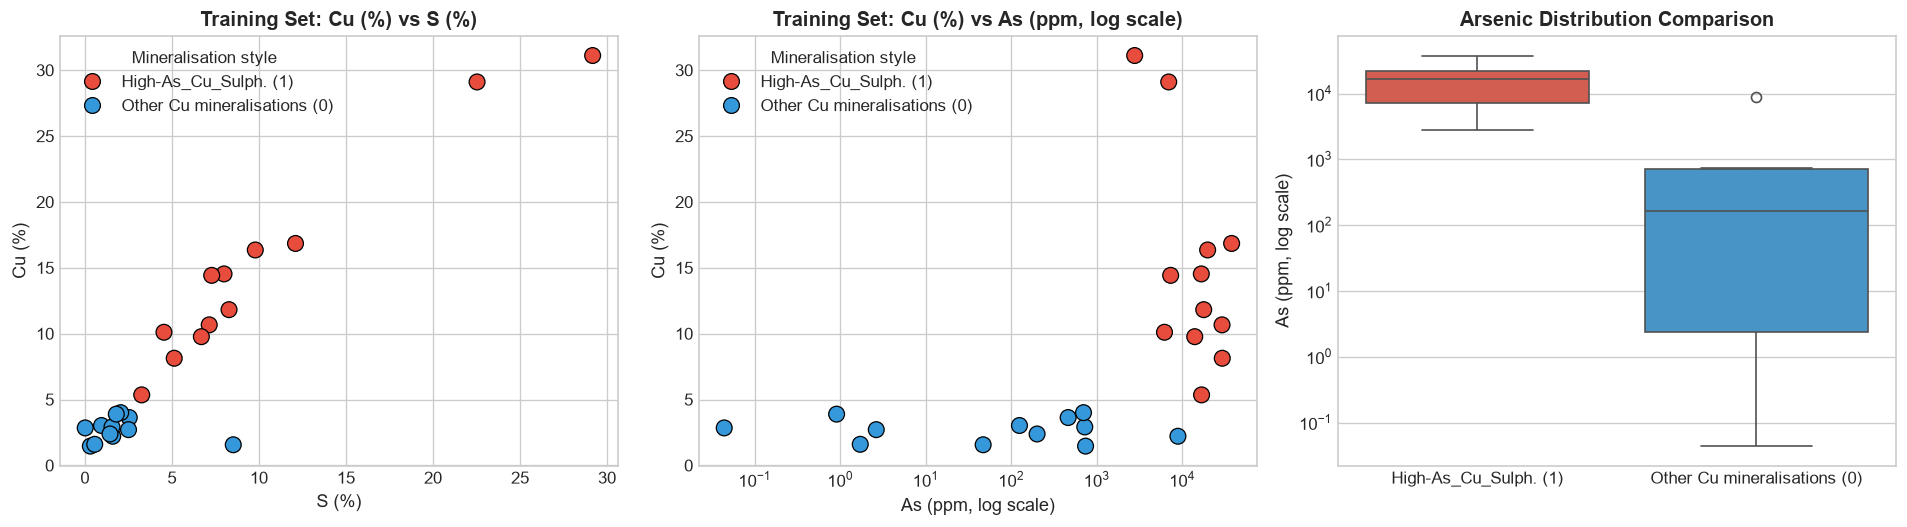

In [8]:
# Geochemical Harker plots to highlight the characteristics of the high-As Cu sulphide mineralisation style
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
#setting the color for the datapoints according to the mineralisation style
palette = {0: '#3498db', 1: '#e74c3c'}

labels = {0: 'Other Cu mineralisations (0)', 1: 'High-As_Cu_Sulph. (1)'}
df_train['Mineralisation style'] = df_train['Is_High_As_Cu_Sulph'].map(labels)

# 1. Cu vs S
sns.scatterplot(
    data=df_train, x='S_pct', y='Cu_pct', hue='Mineralisation style',
    palette={'Other Cu mineralisations (0)': '#3498db', 'High-As_Cu_Sulph. (1)': '#e74c3c'},
    s=90, edgecolor='black', ax=axes[0]
)
axes[0].set_title('Training Set: Cu (%) vs S (%)', fontweight='bold')
axes[0].set_xlabel('S (%)')
axes[0].set_ylabel('Cu (%)')

# 2. Cu vs As (As in log scale)
sns.scatterplot(
    data=df_train, x='As_ppm', y='Cu_pct', hue='Mineralisation style',
    palette={'Other Cu mineralisations (0)': '#3498db', 'High-As_Cu_Sulph. (1)': '#e74c3c'},
    s=90, edgecolor='black', ax=axes[1]
)
axes[1].set_xscale('log')
axes[1].set_title('Training Set: Cu (%) vs As (ppm, log scale)', fontweight='bold')
axes[1].set_xlabel('As (ppm, log scale)')
axes[1].set_ylabel('Cu (%)')

# 3. Boxplot of As_ppm
sns.boxplot(
    data=df_train, x='Mineralisation style', y='As_ppm',
    palette={'Other Cu mineralisations (0)': '#3498db', 'High-As_Cu_Sulph. (1)': '#e74c3c'},
    legend=False,
    ax=axes[2]
)
axes[2].set_yscale('log')
axes[2].set_title('Arsenic Distribution Comparison', fontweight='bold')
axes[2].set_ylabel('As (ppm, log scale)')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()


## Step 5: XGBoost Model Training & 5-Fold Cross-Validation
We configure an `XGBClassifier` with:
- `colsample_bytree = 0.7`: Subsamples 70% of features at each split, preventing over-reliance on Cu alone and enforcing the multi-element Cu-S-As association.
- `subsample = 0.8`: Subsamples 80% of rows to prevent overfitting on small training samples.
- `learning_rate = 0.05`, `max_depth = 3`, `n_estimators = 100`.
- Evaluated with **5-Fold Stratified Cross-Validation on RD 997 dataset**.


In [9]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    colsample_bytree=0.7,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)

# 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_proba = cross_val_predict(xgb_model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
cv_pred = (cv_proba >= 0.5).astype(int)

cv_roc_auc = roc_auc_score(y_train, cv_proba)
cv_pr_auc = average_precision_score(y_train, cv_proba)

print(f"5-Fold CV ROC AUC: {cv_roc_auc:.4f}")
print(f"5-Fold CV PR  AUC: {cv_pr_auc:.4f}\n")
print("Classification Report:")
print(classification_report(y_train, cv_pred, target_names=['Other Cu mineralisation (0)', 'High-As Cu Suplh (1)'], digits=4))


5-Fold CV ROC AUC: 0.9792
5-Fold CV PR  AUC: 0.9812

Classification Report:
                             precision    recall  f1-score   support

Other Cu mineralisation (0)     0.9091    0.8333    0.8696        12
       High-As Cu Suplh (1)     0.8462    0.9167    0.8800        12

                   accuracy                         0.8750        24
                  macro avg     0.8776    0.8750    0.8748        24
               weighted avg     0.8776    0.8750    0.8748        24



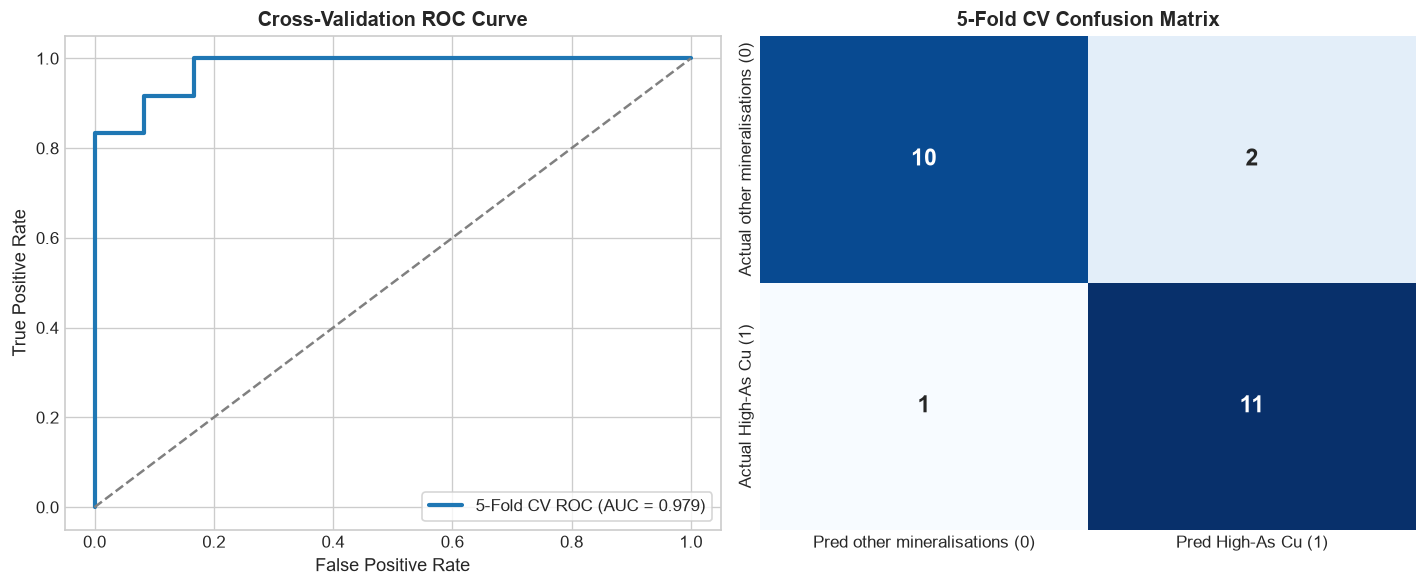

In [10]:
# Plot Model Evaluation Metrics
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. ROC Curve
fpr, tpr, _ = roc_curve(y_train, cv_proba)
axes[0].plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'5-Fold CV ROC (AUC = {cv_roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--')
axes[0].set_title('Cross-Validation ROC Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right', frameon=True)

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_train, cv_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1],
            xticklabels=['Pred other mineralisations (0)', 'Pred High-As Cu (1)'],
            yticklabels=['Actual other mineralisations (0)', 'Actual High-As Cu (1)'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_title('5-Fold CV Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.show()


## Step 6: Feature Importance & Chemical Verification
We fit the final XGBoost model on the complete balanced training dataset and analyze relative feature gain importances.


C:\Users\cesar\AppData\Local\Temp\ipykernel_4200\2485147223.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='Importance_Gain', y='Feature', palette='mako', edgecolor='black')


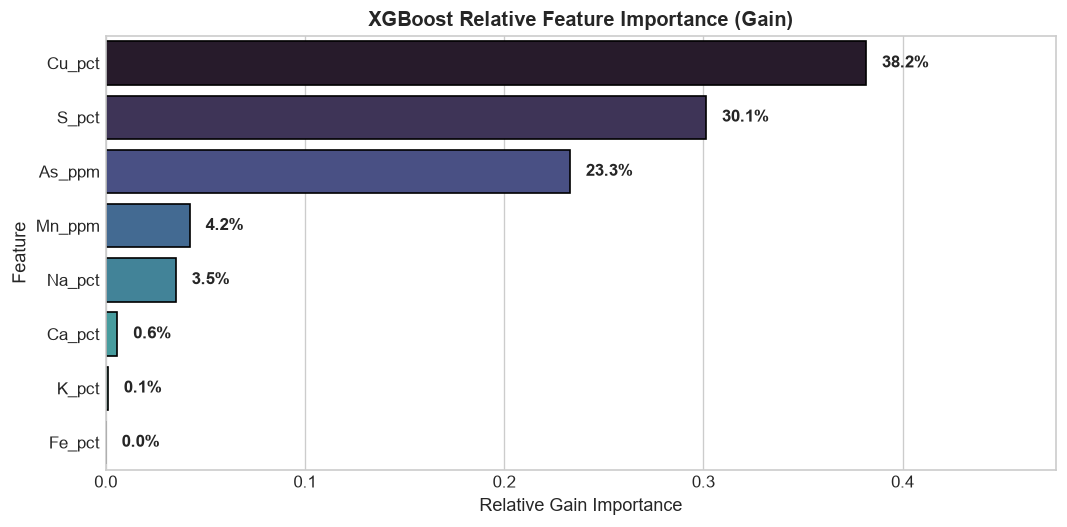

Model saved to: xgboost_high_as_Cu_sulph_model.json


In [11]:
# Fit model on complete balanced dataset
xgb_model.fit(X_train, y_train)

# Calculate feature importances
importances = pd.DataFrame({
    'Feature': element_features,
    'Importance_Gain': xgb_model.feature_importances_
}).sort_values('Importance_Gain', ascending=False)

# Plot feature importances
plt.figure(figsize=(9, 4.5))
sns.barplot(data=importances, x='Importance_Gain', y='Feature', palette='mako', edgecolor='black')
plt.title('XGBoost Relative Feature Importance (Gain)', fontweight='bold')
plt.xlabel('Relative Gain Importance')
for i, v in enumerate(importances['Importance_Gain']):
    plt.text(v + 0.008, i, f"{v*100:.1f}%", va='center', fontweight='bold', fontsize=10)
plt.xlim(0, max(importances['Importance_Gain']) * 1.25)
plt.tight_layout()
plt.show()

# Save model artifact
xgb_model.save_model("xgboost_high_as_Cu_sulph_model.json")
print("Model saved to: xgboost_high_as_Cu_sulph_model.json")


## Step 7: Inference on Other Drillcores (`Cu_pct_other_drillcores_filtered.csv`)
We now apply the trained model to predict the presence of the High-As Sulphosalt ore facies across 283 core samples in `MQ187`, `Mungana 883`, and `Mungana 845`.


In [17]:
# Extract features from target dataset
X_target = df_target[element_features].copy()

# Generate predictions & probability scores
target_proba = xgb_model.predict_proba(X_target)[:, 1]
target_preds = (target_proba >= 0.5).astype(int)

df_target['Pred_Is_High_As_Cu_Sulph'] = target_preds             
df_target['Pred_Probability'] = np.round(target_proba, 4)         

# Save annotated target dataset
target_out_path = "Cu_pct_other_drillcores_with_High_As_Cu_Sulph_predictions.csv"
try:
    df_target.to_csv(target_out_path, index=False)
except PermissionError:
    target_out_path = "Cu_pct_other_drillcores_with_High_As_Cu_Sulph_predictions_v2.csv"
    df_target.to_csv(target_out_path, index=False)

print(f"Predictions saved to: {target_out_path}")
print(f"Total core samples processed: {len(df_target)}")
print(f"Predicted High-As Cu sulph.: {sum(target_preds == 1)} ({sum(target_preds == 1)/len(df_target)*100:.1f}%)")
print(f"Predicted other Cu mineralistion styles:          {sum(target_preds == 0)} ({sum(target_preds == 0)/len(df_target)*100:.1f}%)")


Predictions saved to: Cu_pct_other_drillcores_with_High_As_Cu_Sulph_predictions.csv
Total core samples processed: 283
Predicted High-As Cu sulph.: 18 (6.4%)
Predicted other Cu mineralistion styles:          265 (93.6%)


In [18]:
# Predictions breakdown by drillhole
crosstab = pd.crosstab(df_target['DDH_name'], df_target['Pred_Is_High_As_Cu_Sulph'], margins=True)
crosstab.columns = ['Predicted other mineralisations (0)', 'Predicted High-As Cu sulph.(1)', 'Total']
crosstab


,Predicted other mineralisations (0),Predicted High-As Cu sulph.(1),Total
DDH_name,,,
MQ187,200,14,214
Mungana 845,18,0,18
Mungana 883,47,4,51
All,265,18,283


In [19]:
# Geochemical validation of predicted classes in target dataset
target_means = df_target.groupby('Pred_Is_High_As_Cu_Sulph')[element_features].mean().T
target_means.columns = ['Predicted other Cu mineralisations (0)', 'Pred_Is_High_As_Cu_Sulph. (1)']
target_means['Ratio (1 / 0)'] = target_means['Pred_Is_High_As_Cu_Sulph. (1)'] / target_means['Predicted other Cu mineralisations (0)']
target_means


,Predicted other Cu mineralisations (0),Pred_Is_High_As_Cu_Sulph. (1),Ratio (1 / 0)
Na_pct,2.759207,3.176417,1.151206
S_pct,0.826579,3.766273,4.556457
K_pct,0.089714,0.023693,0.264090
Ca_pct,18.546518,14.460939,0.779712
Mn_ppm,3192.894340,4425.666667,1.386099
Fe_pct,15.812824,20.885839,1.320817
As_ppm,4794.449057,7638.055556,1.593104
Cu_pct,3.406619,9.836611,2.887500


## Step 8: Spatial Downhole Ore Profiling
We map the identified High-As Sulphosalt intervals against depth along each drillhole to examine the spatial architecture and continuity of the ore intercepts.


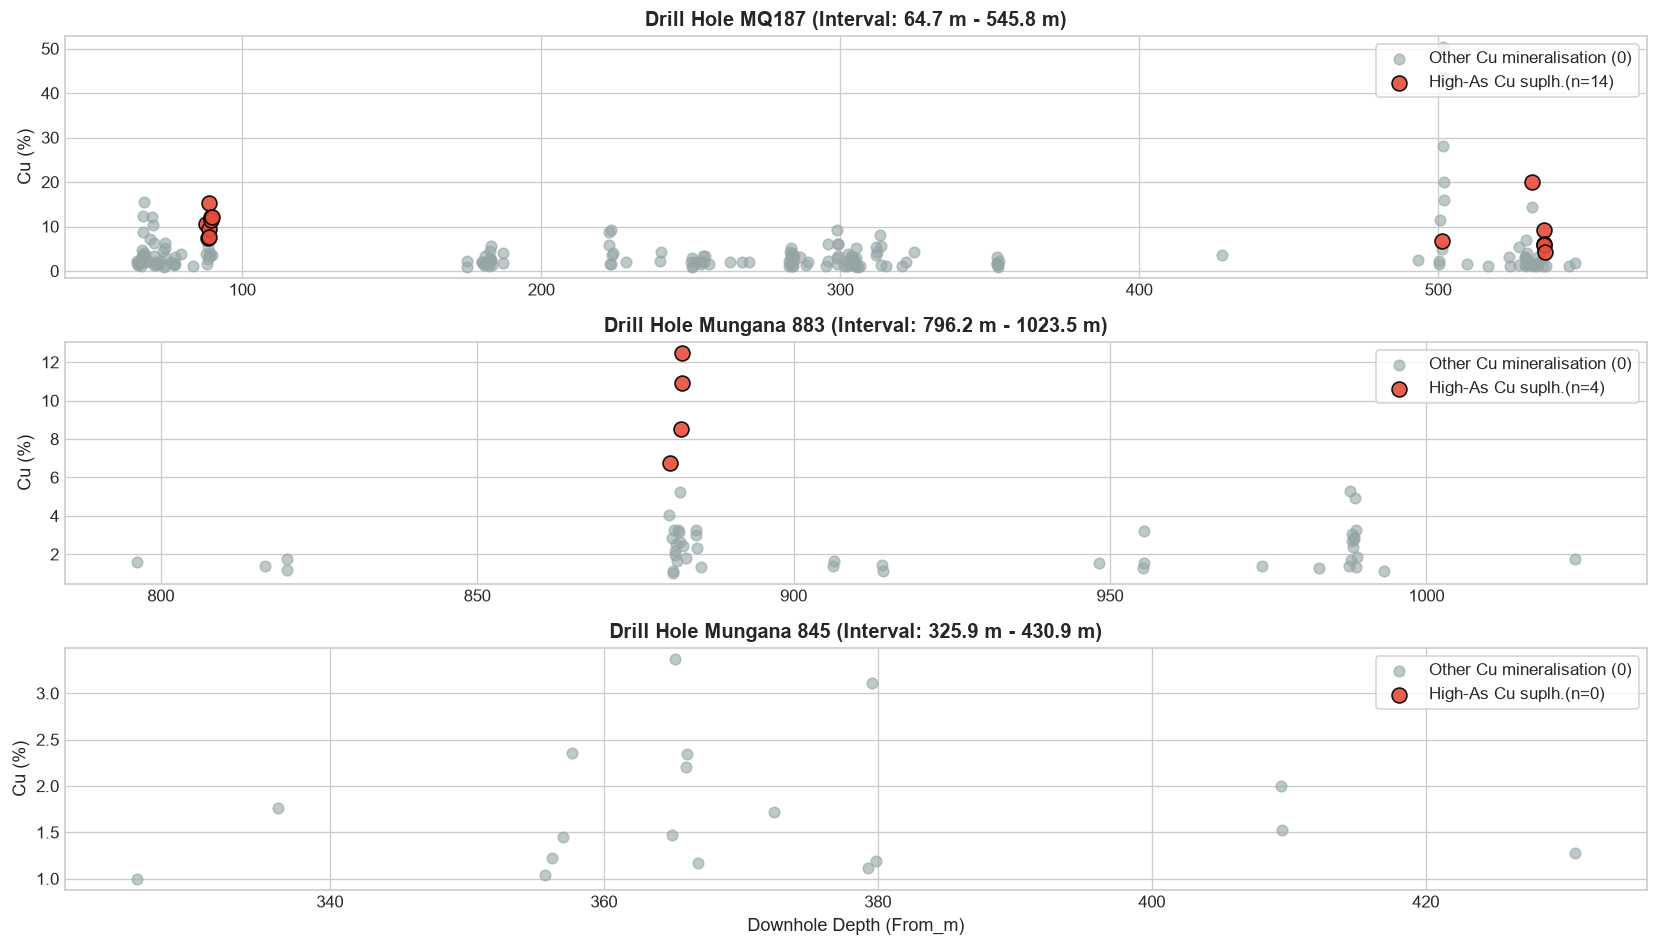

In [23]:
holes = ['MQ187', 'Mungana 883', 'Mungana 845']
fig, axes = plt.subplots(len(holes), 1, figsize=(14, 8), sharex=False)

for i, h in enumerate(holes):
    sub = df_target[df_target['DDH_name'] == h].sort_values('From_m')
    ax = axes[i]
    
    bg = sub[sub['Pred_Is_High_As_Cu_Sulph'] == 0]
    ax.scatter(bg['From_m'], bg['Cu_pct'], color='#95a5a6', alpha=0.6, s=40, label='Other Cu mineralisation (0)')
    
    ore = sub[sub['Pred_Is_High_As_Cu_Sulph'] == 1]
    ax.scatter(ore['From_m'], ore['Cu_pct'], color='#e74c3c', alpha=0.9, s=80, edgecolor='black', 
               label=f'High-As Cu suplh.(n={len(ore)})')
    
    min_d = sub['From_m'].min()
    max_d = sub['From_m'].max()
    ax.set_title(f'Drill Hole {h} (Interval: {min_d:.1f} m - {max_d:.1f} m)', fontweight='bold')
    ax.set_ylabel('Cu (%)')
    ax.legend(loc='upper right', frameon=True)

axes[-1].set_xlabel('Downhole Depth (From_m)')
plt.tight_layout()
plt.show()


## Summary & Geological Insights

1. **Class Balancing technique**:
   - Pulling $12$ stratified background samples from clusters 1, 2, and 3 (other mineralisation styles) in `RD-997` solved the single-class training problem, giving a robust $1:1$ balanced dataset ($N=24$).
2. **Strong Cross-Validation Performance**:
   - 5-Fold CV ROC AUC reached **$0.9792$** and PR AUC reached **$0.9812$**, with an overall accuracy of **$87.5\%$**.
3. **Mineralogically and geochemically sound control factors**:
   - $\text{Cu}$ ($38.2\%$) + $\text{S}$ ($30.1\%$) + $\text{As}$ ($23.3\%$) account for **$91.6\%$** of total model gain, confirming the XGBoost model algorithm is detecting the High-As Cu sulphide-bearing signatures, rather than spurious or random signals.
4. **Target Deposit Predictions**:
   - **MQ187**: 14 high-grade As and potentially chalcopyrite-bearing intervals identified at $\sim 90\text{ m}$ downhole ($\\text{Cu} \\approx 8-15\\%$) and between $501\text{ m}$ and $540\text{ m}$ ($\\text{Cu}$ up to $20\\%$, high As).
   - **Mungana 883**: 4 High-As Cu sulph. intervals identified between $881.7\text{ m}$ and $883.3\text{ m}$ ($\\text{Cu} = 6.8 - 12.6\\%$, high As).
   - **Mungana 845**: 0 samples met the multi-element sulphosalt threshold (peak $\\text{Cu} < 3.5\\%$). This is consistent with the assays see GSQ report.

### Discussion and conclusions
From this case study it can be derived that a significant portion of the Cu mineralisation in most mineralised zones in all the studied drill cores possess sub-layers of either "clean" (that means As ppm < 2000, the conventionally safe bulk-rock threshold). Because the interval at which the "clean" and As-rich mineralised zones occur is on a metric scale, most of these zones cannot be considered "clean" and should be treated as As-bearing for extraction purposes. However, since it appears from previous mineralogical studies (Lehrmann, 2012), that Cu is found mostly in chalcopyrite (As-free), the bulk of As in sequestered in arsenopyrite and to a smaller extent in Cu sulphosalts. This would mean that it may be possible to separate though flotation, thus rendering the As bulk-rock not relevant as it appears on paper unlocking the Cu resources. Instead, where the As-rich oxide mineralisation is present, extraction would be signficantly harder as As is bound to Cu oxide without discrete phases, rendring the ore extremely toxic to process. This needs to be accounted in the mineralised zones containing high-grade As and Cu in the oxide form. 


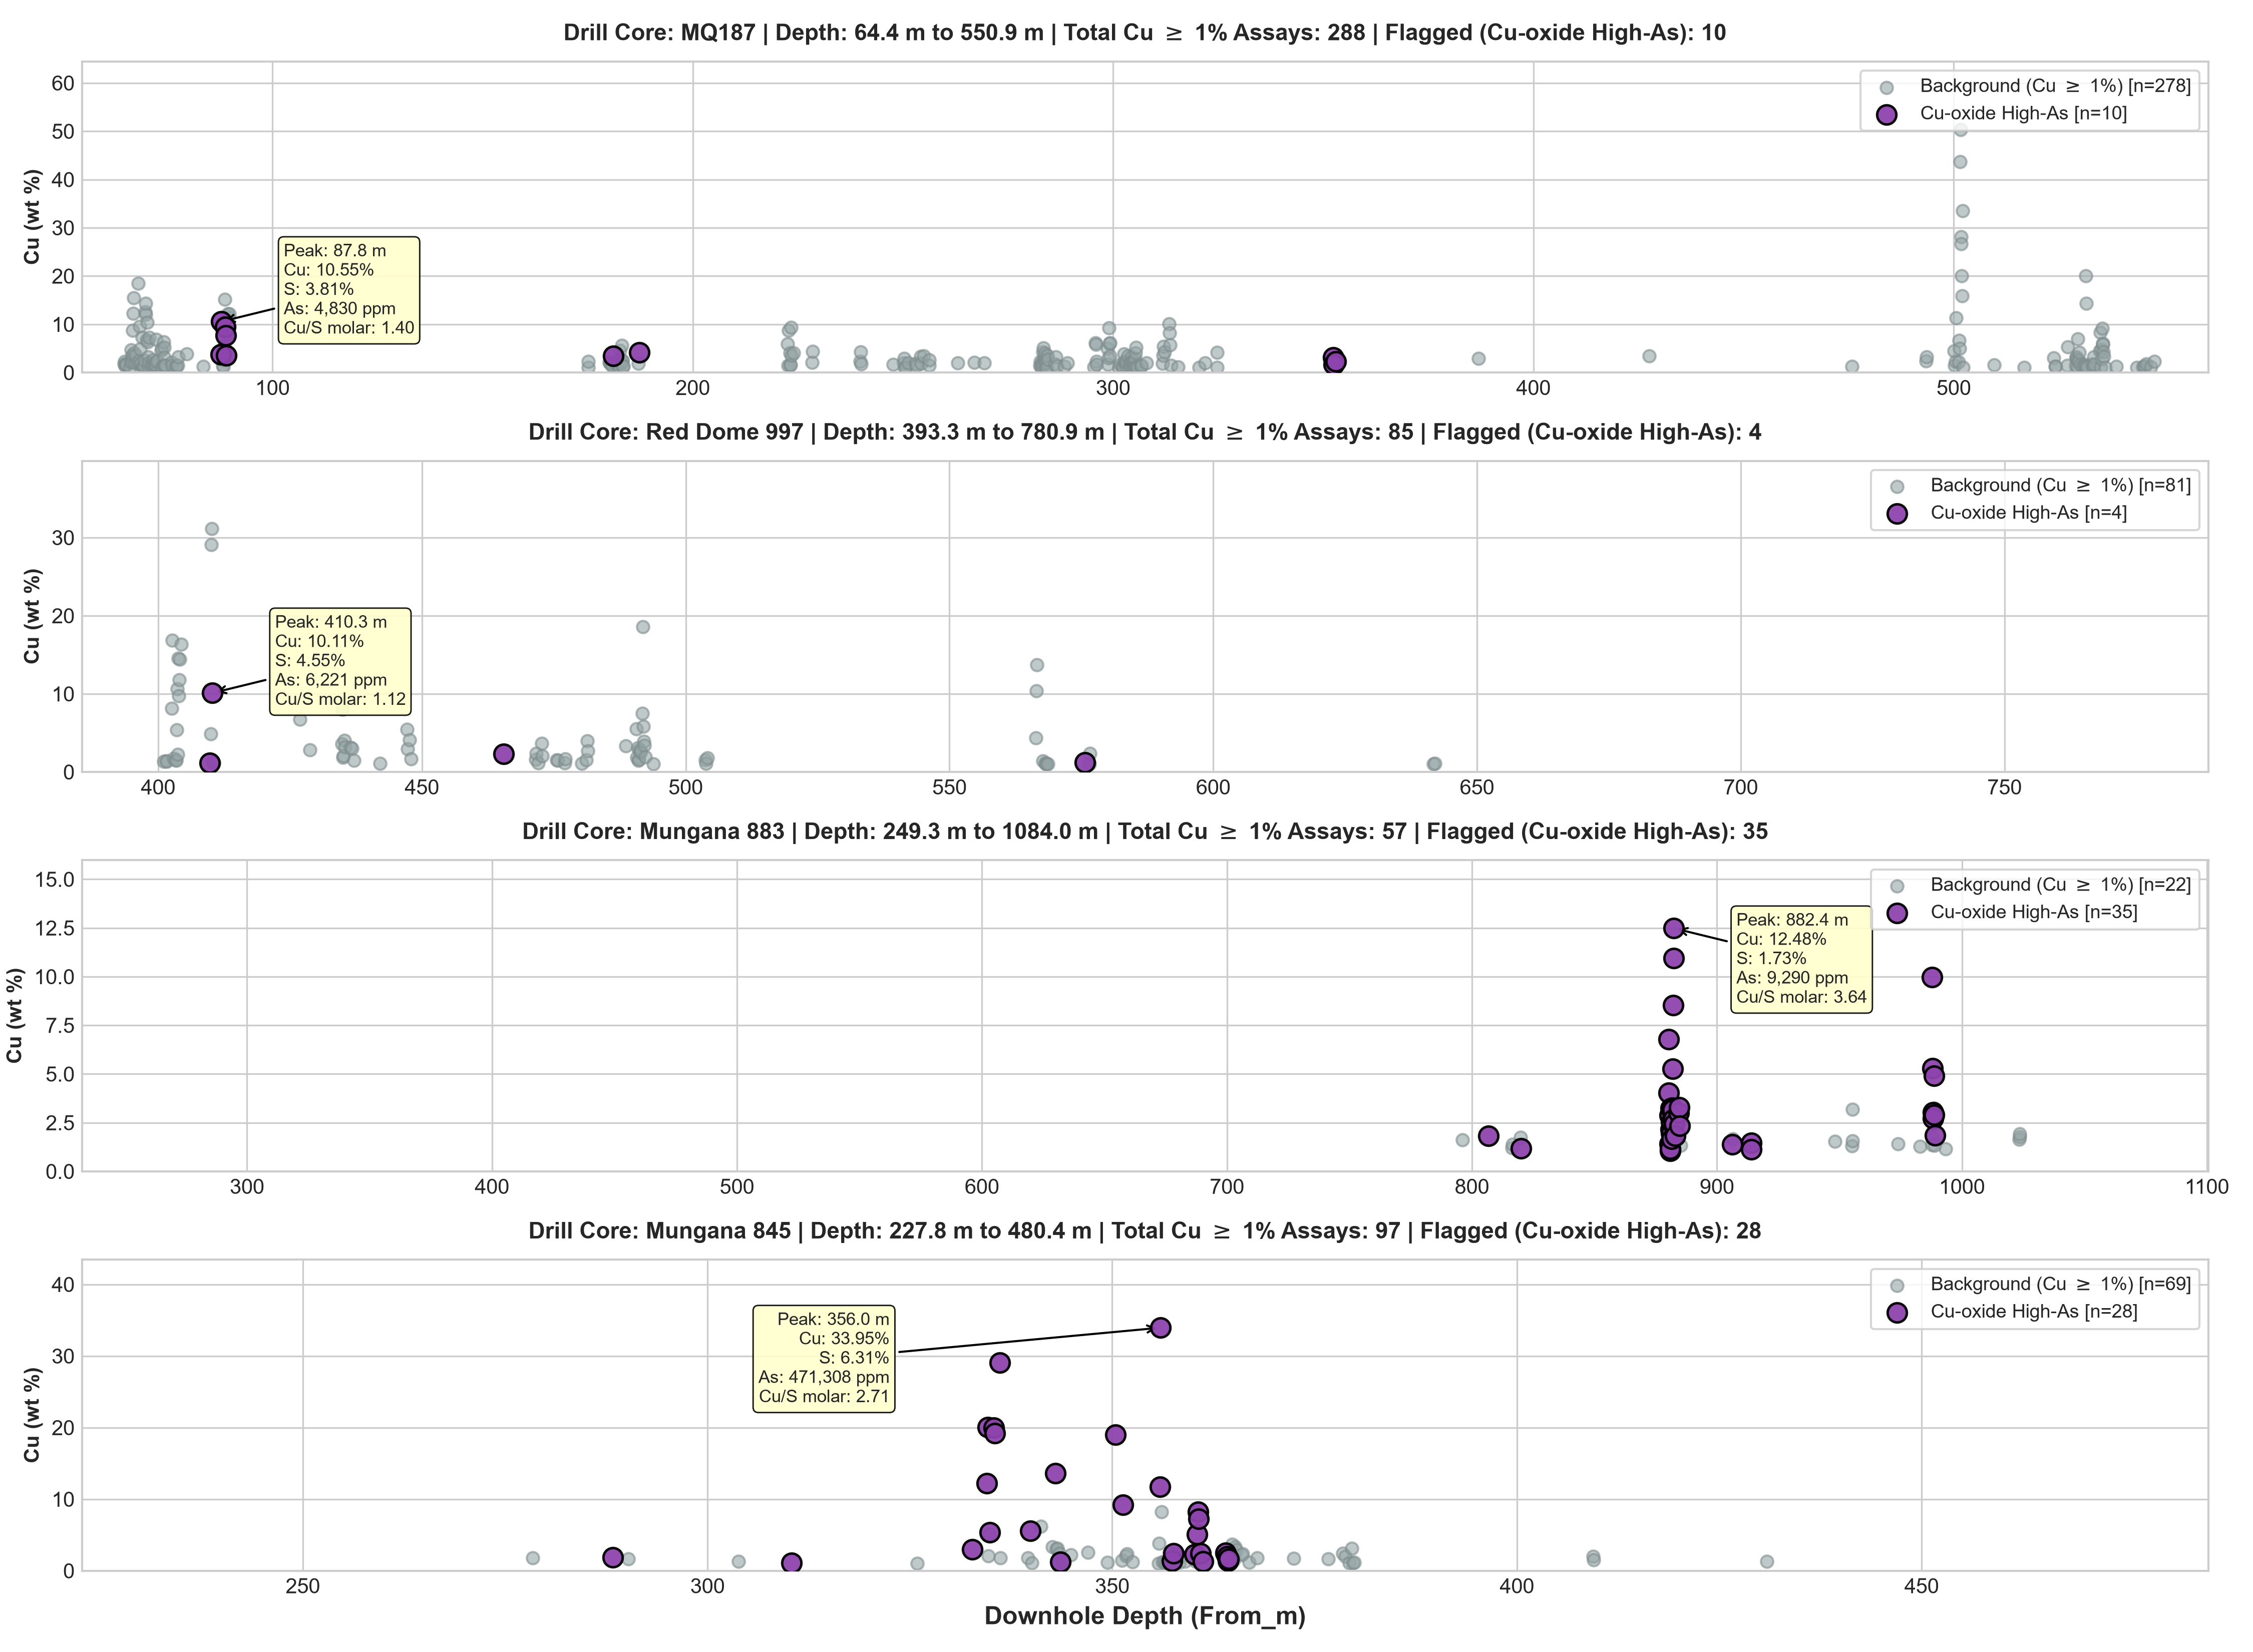
This graph shows where the oxide mineralisation is found. In some of the mineralised zones oxide is adjacent to either the high-As sulphide bearing mineralisation or adjacent to any type of Cu mineralisation. Given the metric scale of mineralisations the occurence of high-As oxide layers would thus be accounted for, as the extraction occurs in the metric scale, so in the extraction process is not possible to discrd the high-As oxide mineralisation that would need later processing, to keep only the chalcopyrite fraction.